In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#url = 'https://raw.githubusercontent.com/mcnakhaee/palmerpenguins/refs/heads/master/palmerpenguins/data/penguins.csv'
#url2 =  'https://raw.githubusercontent.com/mcnakhaee/palmerpenguins/refs/heads/master/palmerpenguins/data/penguins-raw.csv'

url = './data/penguins.csv'
penguins = pd.read_csv(url)

print(penguins.shape)
penguins.head()

(344, 8)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [11]:
# Create df for ML
df = penguins

---
## Regression
---

In [12]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_predict

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor


from scipy import stats  # needed for Q-Q plot

In [52]:
# ---------------------------------------------------
# 1) X, y Definitions
# ---------------------------------------------------

# Target = body_mass_g
df = df.dropna(subset=['body_mass_g'])
num_cols = ['bill_length_mm','bill_depth_mm','flipper_length_mm']
cat_cols = ['species','island','sex']
X = df[num_cols + cat_cols]
y = df['body_mass_g']

In [53]:
df.shape

(342, 8)

In [54]:
# ---------------------------------------------------
# 2) Preprocessing Pipelines
# ---------------------------------------------------
numeric_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), 
                             ('scaler', StandardScaler())])
categorical_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), 
                                 ('ohe', OneHotEncoder(handle_unknown='ignore', drop='first'))])
preprocess = ColumnTransformer([('num', numeric_pipeline, num_cols), 
                                ('cat', categorical_pipeline, cat_cols)])

In [55]:
#numeric_pipeline
#categorical_pipeline
preprocess

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [56]:
# ---------------------------------------------------
# 3) Regression Model (Random Forest Regression)
# ---------------------------------------------------

reg = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=500
    ))
])

In [57]:
reg

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [58]:
# ---------------------------------------------------
# 4) Train-Test Split
# ---------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# ---------------------------------------------------
# 5) Fit the model
# ---------------------------------------------------
reg.fit(X_train, y_train)

# ---------------------------------------------------
# 6) Evaluate performance
# ---------------------------------------------------
y_pred = reg.predict(X_test)


mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print('RMSE:', rmse)
print('R2:', r2_score(y_test, y_pred))

RMSE: 331.9820049252713
R2: 0.850061485458907


In [59]:
cv = cross_val_score(reg, X, y, cv=7, scoring='r2')
print('CV R2:', cv.mean())

CV R2: 0.5753958085567712


In [60]:
cv

array([0.52135146, 0.48281139, 0.41737857, 0.70392348, 0.74394662,
       0.86957532, 0.28878381])

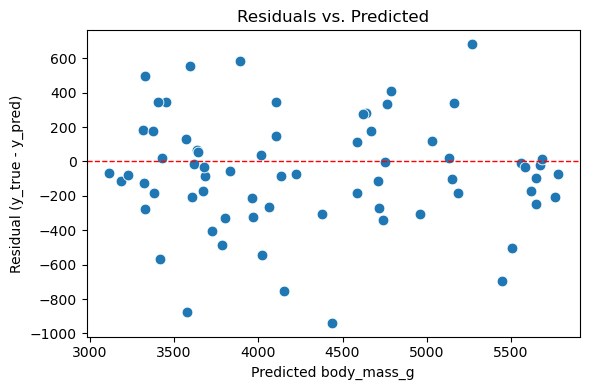

In [61]:
# ---------------------------------------------------
# 7) Residuals vs Predicted
# ---------------------------------------------------

# Residuals
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=residuals, edgecolor="w", s=60)
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.xlabel("Predicted body_mass_g")
plt.ylabel("Residual (y_true - y_pred)")
plt.title("Residuals vs. Predicted")
plt.tight_layout()
plt.show()

**Interpretation tips:**  

* Random cloud around 0 → good.
* Curves/patterns → model misspecification (nonlinearity).
* Fan shape → heteroscedasticity (variance changes with prediction).

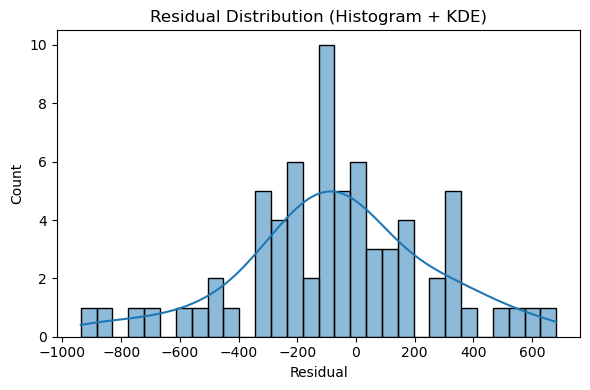

In [62]:
# Residual Distribution
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True, bins=30)
plt.xlabel("Residual")
plt.title("Residual Distribution (Histogram + KDE)")
plt.tight_layout()
plt.show()

**Interpretation tips:**

* Roughly bell‑shaped & centered near 0 is ideal.
* Heavy tails / skew may affect confidence intervals and some metrics.

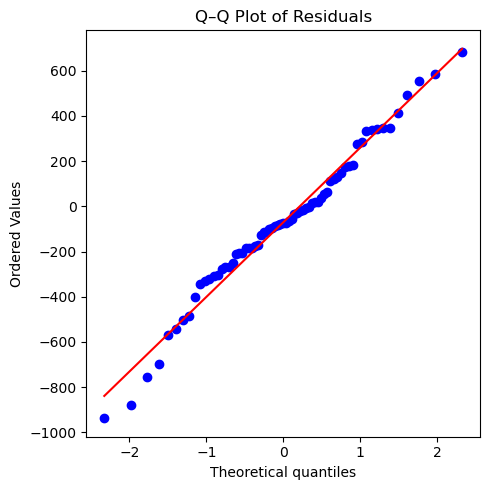

In [63]:
# Q-Q Plot (quantile-quantile vs Normal)

plt.figure(figsize=(5,5))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q–Q Plot of Residuals")
plt.tight_layout()
plt.show()

**Interpretation tips:**

* Points near the line → residuals are close to normal.
* S‑shaped deviations → skew / heavy tails.

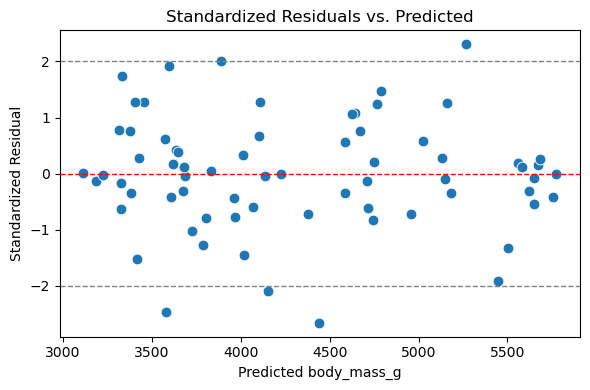

In [64]:
# Standardized Residuals vs. Predicted (spot outliers)
std_residuals = (residuals - np.mean(residuals)) / np.std(residuals, ddof=1)

plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=std_residuals, edgecolor="w", s=60)
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.axhline(2, color="gray", linestyle="--", linewidth=1)
plt.axhline(-2, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Predicted body_mass_g")
plt.ylabel("Standardized Residual")
plt.title("Standardized Residuals vs. Predicted")
plt.tight_layout()
plt.show()

**Interpretation tips:**

* Points beyond ±2 (or ±3) may be potential outliers/influential cases.

C:\Users\biauser\anaconda3\envs\ds312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


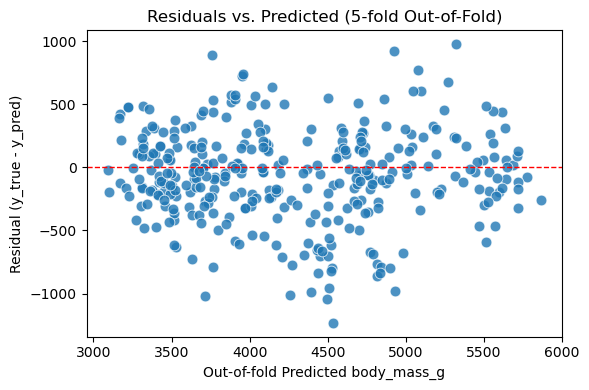

In [65]:
# Cross-validated predictions for residual diagnostics


y_cv_pred = cross_val_predict(reg, X, y, cv=5)   # uses your full pipeline 'reg'
cv_residuals = y - y_cv_pred

plt.figure(figsize=(6,4))
sns.scatterplot(x=y_cv_pred, y=cv_residuals, edgecolor="w", s=60, alpha=0.8)
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.xlabel("Out-of-fold Predicted body_mass_g")
plt.ylabel("Residual (y_true - y_pred)")
plt.title("Residuals vs. Predicted (5-fold Out-of-Fold)")
plt.tight_layout()
plt.show()

* residuals that reflect out‑of‑fold predictions (each point predicted by a model that didn’t see it during training)